In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_OW_pos_fold0_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_OW_pos_fold1_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_OW_pos_fold2_0.5_selected_genomic_windows_centered_results.tsv", sep="\t")
fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
len(df)

164

In [7]:
len(df[df["dot_result"] <= 0.0])

1

In [ ]:
df.columns

In [8]:
df = df[df["dot_result"] > 0.0]

In [ ]:
df.columns

In [9]:
len(df[(df["CTCFs_num_slice0"] == 0) & (df["CTCFs_num_slice1"] == 0)])

32

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,...,FIMO_sum_slice0,FIMO_max_slice0,orientation_slice0,positions_slice0,init_CTCFs_num_slice1,CTCFs_num_slice1,FIMO_sum_slice1,FIMO_max_slice1,orientation_slice1,positions_slice1
0,chr1,37793792,39104512,0,0.861165,195.0,323.0,37799936,39110656,192,...,32.660454,12.419272,+-+,"[(101, 120), (444, 463), (453, 472)]",0,0,0.000000,0.000000,no,()
1,chr11,65921024,67231744,0,0.746112,76.0,199.0,65677312,66988032,195,...,0.000000,0.000000,no,(),0,0,0.000000,0.000000,no,()
2,chr3,38414336,39725056,0,0.670098,198.0,422.0,38524928,39835648,144,...,0.000000,0.000000,no,(),0,0,0.000000,0.000000,no,()
3,chr3,40978432,42289152,0,0.754782,82.0,182.0,40724480,42035200,206,...,14.332623,14.332623,-,"[(261, 280)]",0,0,0.000000,0.000000,no,()
4,chr3,51795968,53106688,0,0.855747,247.0,416.0,51949568,53260288,172,...,0.000000,0.000000,no,(),0,1,11.749246,11.749246,+,"[(1785, 1804)]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,chr9,99520512,100831232,2,0.903110,188.0,332.0,99528704,100839424,184,...,22.243976,22.243976,+,"[(397, 416)]",1,0,0.000000,0.000000,no,()
160,chr9,101486592,102797312,2,0.841365,58.0,329.0,101357568,102668288,121,...,8.610605,8.610605,+,"[(1176, 1195)]",0,1,9.354905,9.354905,+,"[(1324, 1343)]"
161,chr9,104108032,105418752,2,0.792664,193.0,360.0,104148992,105459712,173,...,9.218634,9.218634,+,"[(691, 710)]",1,0,0.000000,0.000000,no,()
162,chr9,111015936,112326656,2,0.832669,222.0,341.0,111067136,112377856,197,...,0.000000,0.000000,no,(),0,1,14.781296,14.781296,-,"[(1121, 1140)]"


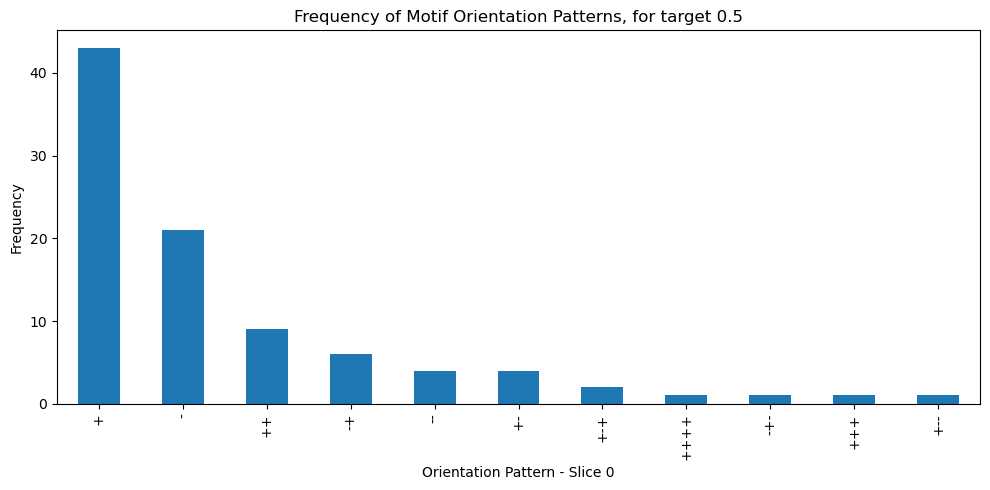

In [12]:
orientation_counts = df[df['orientation_slice0'] != "no"]['orientation_slice0'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Slice 0")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

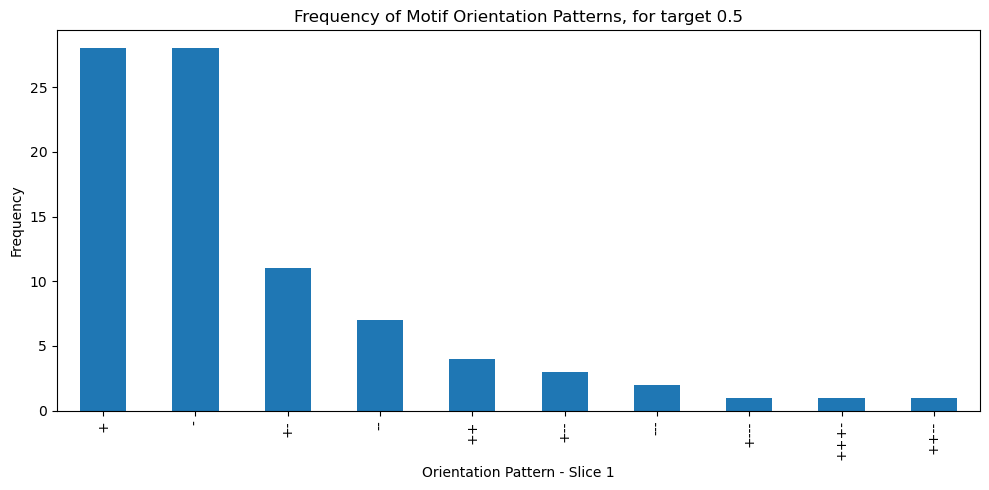

In [13]:
orientation_counts = df[df['orientation_slice1'] != "no"]['orientation_slice1'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Slice 1")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [14]:
df["orientation"] = np.where(
    (df["orientation_slice0"] == "no") | (df["orientation_slice1"] == "no"),
    "no",
    df["orientation_slice0"] + df["orientation_slice1"]
)

In [ ]:
# df["orientation"] = df.apply(
#     lambda row: "no"
#     if row["orientation_slice0"] == "no" and row["orientation_slice1"] == "no"
#     else row["orientation_slice0"].replace("no", "") + row["orientation_slice1"].replace("no", ""),
#     axis=1
# )

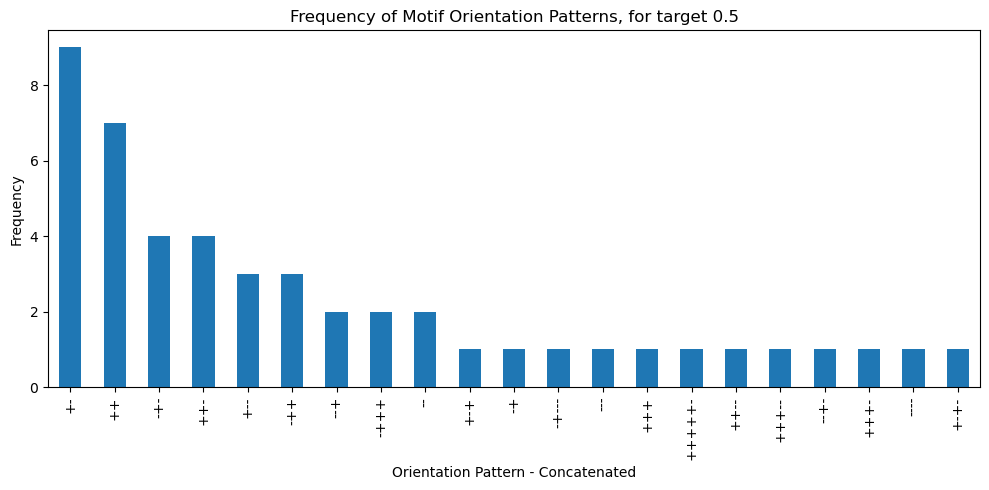

In [15]:
orientation_counts = df[df['orientation'] != "no"]['orientation'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern - Concatenated")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [16]:
dot_strength_df = pd.read_csv("/scratch1/smaruj/natural_dots/filtered_dots_results.tsv", sep="\t")

In [17]:
dot_strength_df

,chrom,BIN1_START,BIN1_END,BIN2_START,BIN2_END,FDR,DETECTION_SCALE,window_start,window_end,anchor2_center_bin,anchors_dist,anchor1_center_bin,dot_strength
0,chr1,91970000,91980000,92450000,92460000,0.011590,2.111213,91536592,92847312,384,234,150,0.547183
1,chr1,91970000,91980000,92610000,92620000,0.036990,2.599208,91696592,93007312,384,312,72,0.508047
2,chr1,92160000,92170000,92450000,92460000,0.038089,2.111213,91536592,92847312,384,141,243,0.153592
3,chr1,92490000,92500000,92610000,92620000,0.017336,3.200000,91696592,93007312,384,58,326,0.405669
4,chr1,92680000,92690000,92850000,92860000,0.009500,4.222425,91936592,93247312,384,83,301,0.660956
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,chr19,36140000,36150000,36440000,36450000,0.013890,6.400000,35526592,36837312,384,146,238,0.802921
6814,chr19,36180000,36190000,36430000,36440000,0.000199,2.111213,35516592,36827312,384,122,262,1.466857
6815,chr19,37050000,37060000,37260000,37270000,0.030770,2.111213,36346592,37657312,384,102,282,0.997232
6816,chr19,37550000,37560000,37930000,37940000,0.037086,2.599208,37016592,38327312,384,185,199,0.444799


In [19]:
print(combined_df["Type"].value_counts())

Type
Natural       6818
dot_init       163
dot_result     163
Name: count, dtype: int64


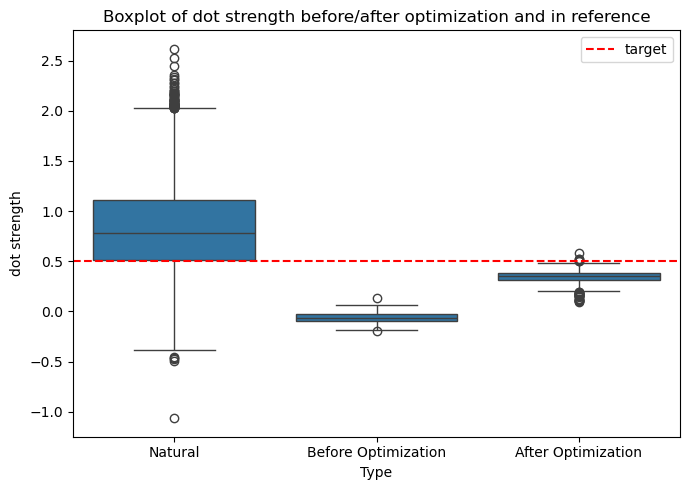

In [21]:
df_melted = df.melt(value_vars=['dot_init', 'dot_result'], var_name='Type', value_name='dot strength')

df_melted["Type"] = df_melted["Type"].replace({
    "dot_init": "Before Optimization",
    "dot_result": "After Optimization"
})

# Format the new dot_strength data
dot_strength_extra = pd.DataFrame({
    'Type': ['Natural'] * len(dot_strength_df),
    'dot strength': dot_strength_df["dot_strength"]
})

# Concatenate both
combined_df = pd.concat([dot_strength_extra, df_melted], ignore_index=True)

# Plot
plt.figure(figsize=(7, 5))
sns.boxplot(x='Type', y='dot strength', data=combined_df, order=['Natural', 'Before Optimization', 'After Optimization'])
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='target')
plt.title('Boxplot of dot strength before/after optimization and in reference')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df["init_CTCFs_num"] = df["init_CTCFs_num_slice0"] + df["init_CTCFs_num_slice1"]
df["CTCFs_num"] = df["CTCFs_num_slice0"] + df["CTCFs_num_slice1"]

In [ ]:
df_box_melted = df.melt(value_vars=['init_CTCFs_num', 'CTCFs_num'],
                            var_name='num_ctcfs', value_name='CTCF Count')

# Rename the categories for clarity
label_map = {
    'init_CTCFs_num': 'Before Optimization',
    'CTCFs_num': 'After Optimization'
}
df_box_melted['num_ctcfs'] = df_box_melted['num_ctcfs'].map(label_map)

# Plotting
plt.figure(figsize=(6, 5))
sns.boxplot(x='num_ctcfs', y='CTCF Count', data=df_box_melted)
plt.title('CTCF Count (both slices) Before and After Optimization')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

In [ ]:
df.columns

In [ ]:
# Calculate Pearson correlation coefficient
r_value, p_value = pearsonr(df['dot_target'], df['dot_result'])

In [ ]:
# Determine shared range for both axes
min_val = min(df['dot_target'].min(), df['dot_result'].min())
max_val = max(df['dot_target'].max(), df['dot_result'].max())

# Plotting the scatterplot with equal axis limits and square aspect ratio
plt.figure(figsize=(6, 6))
sns.scatterplot(x='dot_target', y='dot_result', data=df)
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')  # reference diagonal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Pearson r = {r_value:.2f}')
plt.xlabel('target dot mean')
plt.ylabel('result dot mean')
plt.tight_layout()
plt.show()


In [ ]:

# Compute PearsonR and p-value
r, p = pearsonr(df['CTCFs_num'], df['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='dot_result', data=df)

# Add labels and title
plt.xlabel('CTCFs_num')
plt.ylabel('result dot mean')
plt.title('Scatterplot of CTCFs_num vs result dot mean')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [ ]:
df["dot_diff"] = df["dot_result"] - df["dot_init"]

In [ ]:
# Compute PearsonR and p-value
r, p = pearsonr(df['CTCFs_num'], df['dot_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='CTCFs_num', y='dot_diff', data=df)

# Add labels and title
plt.xlabel('CTCFs_num')
plt.ylabel('result dot mean difference')
plt.title('Scatterplot of CTCFs_num vs result dot mean')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [ ]:
df["FIMO_sum"] = df["FIMO_sum_slice0"] + df["FIMO_sum_slice1"]

In [ ]:
df["FIMO_max"] = df[["FIMO_max_slice0", "FIMO_max_slice1"]].max(axis=1)

In [ ]:
df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df_part['FIMO_sum'], df_part['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='dot_result', data=df_part)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result dot mean')
plt.title('FIMO_sum vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [ ]:
# df_part = df[df["FIMO_sum"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df['FIMO_sum'], df['dot_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_sum', y='dot_diff', data=df)

# Add labels and title
plt.xlabel('FIMO sum')
plt.ylabel('result dot mean difference')
plt.title('FIMO_sum vs dot_diff')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [ ]:
# df_part = df[df["FIMO_max"] > 0]

# Compute PearsonR and p-value
r, p = pearsonr(df['FIMO_max'], df['dot_result'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='dot_result', data=df)

# Add labels and title
plt.xlabel('FIMO_max')
plt.ylabel('result dot mean')
plt.title('FIMO_max vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [ ]:
# Compute PearsonR and p-value
r, p = pearsonr(df['FIMO_max'], df['dot_diff'])

# Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x='FIMO_max', y='dot_result', data=df)

# Add labels and title
plt.xlabel('FIMO_max')
plt.ylabel('result dot mean difference')
plt.title('FIMO_max vs dot_result')

# Annotate PearsonR in top right corner
plt.text(
    0.95, 0.95,
    f"PearsonR = {r:.3f}, p-value = {p:.3f}",
    transform=plt.gca().transAxes,
    ha='right', va='top',
    fontsize=11, color='black'
)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='last_accepted_step',
    y='GC_seq',
    data=df
)
plt.xlabel('last step with accepted edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

In [ ]:
df["num_edits"] = df["num_edits_slice0"] + df["num_edits_slice1"] 

In [ ]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='num_edits',
    y='GC_seq',
    data=df
)

plt.xlabel('number of edits')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

In [ ]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    x='dot_diff',
    y='GC_seq',
    data=df
)

plt.xlabel('result dot mean difference')
plt.ylabel('GC content of the genomic sequence')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()


In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='last_accepted_step_query',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Last Step with Accepted Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='active_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Active Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='neutral_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Neutral Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the scatterplot with hue based on optimization success
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='repressive_fraction',
    y='num_edits',
    data=df,
    hue='optimization_successful',
    palette={True: 'blue', False: 'red'}
)
plt.xlabel('Repressive Chromatin Fraction')
plt.ylabel('Number of Edits')
plt.legend(title='Optimization Successful', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
fold_map = {0: 'test', 1: 'valid', 2: 'train'}
df['set'] = df['fold'].map(fold_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='last_accepted_step', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Last Step with Accepted Edits')
plt.tight_layout()
plt.show()

In [ ]:
# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='set', y='num_edits', data=df, order=['train', 'valid', 'test'])
plt.xlabel('Fold')
plt.ylabel('Number of Edits')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_rel

In [ ]:
df.columns

In [ ]:
t_stat, p_val = ttest_rel(df['GC_slice0'], df['GC_slice0_edited'])

In [ ]:
t_stat, p_val

In [ ]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice0', 'GC_slice0_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice0': 'Before Optimization',
    'GC_slice0_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice0\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
t_stat, p_val = ttest_rel(df['GC_slice1'], df['GC_slice1_edited'])

In [ ]:
# Melt the DataFrame for plotting
df_gc_melted = df.melt(value_vars=['GC_slice1', 'GC_slice1_edited'],
                          var_name='Stage', value_name='GC Content')

# Rename the stages for clarity
stage_map = {
    'GC_slice1': 'Before Optimization',
    'GC_slice1_edited': 'After Optimization'
}
df_gc_melted['Stage'] = df_gc_melted['Stage'].map(stage_map)

# Plotting the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Stage', y='GC Content', data=df_gc_melted)
plt.title('GC Content of Sequence Slice1\nBefore vs After Optimization')
plt.text(0.5, max(df_gc_melted['GC Content']) + 0.005,
         f'p = {p_val:.3g}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()